# Phase 1: Data Preparation & Exploratory Data Analysis

This notebook demonstrates the initial stages of our Insurance Claims Risk Analytics project. Our goal is to ingest raw actuarial data (French Motor Third-Party Liability), clean it, engineer relevant risk features, and explore the key drivers of claim frequency and severity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import warnings

warnings.filterwarnings('ignore')
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("muted")

## 1. Data Ingestion
We start by loading the frequency (policy details) and severity (claim amounts) datasets and merging them. We handle the `arff` format manually due to `scipy.io.arff` limitations with string attributes.

In [2]:
# Note: In the source code, we use a custom parser in src/load_data.py
# Here, we will load the already parsed and merged dataset for analysis
merged_df = pd.read_csv('../data/processed/features.csv')
print(f"Dataset shape: {merged_df.shape}")
merged_df.head()

Dataset shape: (678013, 21)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,...,Region,ClaimAmount_total,is_high_risk,ClaimFrequency,HasClaim,AvgSeverity,DrivAgeBand,VehAgeBand,Premium,LossRatio
0,1,1,0.10,D,5,0,55,50,B12,Regular,...,R82,0.0,0,10.000000,1,0.0,41-60,0-2,135.524827,0.0
1,3,1,0.77,D,5,0,55,50,B12,Regular,...,R82,0.0,0,1.298701,1,0.0,41-60,0-2,135.524827,0.0
2,5,1,0.75,B,6,2,52,50,B12,Diesel,...,R22,0.0,0,1.333333,1,0.0,41-60,0-2,132.036666,0.0
3,10,1,0.09,B,7,0,46,50,B12,Diesel,...,R72,0.0,0,11.111111,1,0.0,41-60,0-2,145.719027,0.0
4,11,1,0.84,B,7,0,46,50,B12,Diesel,...,R72,0.0,0,1.190476,1,0.0,41-60,0-2,145.719027,0.0


## 2. Feature Engineering & Cleaning
In `src/clean_data.py` and `src/feature_engineering.py`, we:
- Clipped extreme `Exposure` values.
- Aggregated claims so each policy has a single `ClaimAmount_total`.
- Calculated `ClaimFrequency` and `AvgSeverity`.
- Created actuarial bins like `DrivAgeBand` and `VehAgeBand`.

Let's view the resulting features:

In [3]:
merged_df[['IDpol', 'Exposure', 'ClaimNb', 'ClaimAmount_total', 'AvgSeverity', 'DrivAgeBand', 'VehAgeBand']].head()

,IDpol,Exposure,ClaimNb,ClaimAmount_total,AvgSeverity,DrivAgeBand,VehAgeBand
0,1,0.10,1,0.0,0.0,41-60,0-2
1,3,0.77,1,0.0,0.0,41-60,0-2
2,5,0.75,1,0.0,0.0,41-60,0-2
3,10,0.09,1,0.0,0.0,41-60,0-2
4,11,0.84,1,0.0,0.0,41-60,0-2


## 3. Exploratory Data Analysis (EDA)
Now we explore the portfolio to uncover insights that will guide our predictive modeling.

### 3.1 Claim Frequency by Region

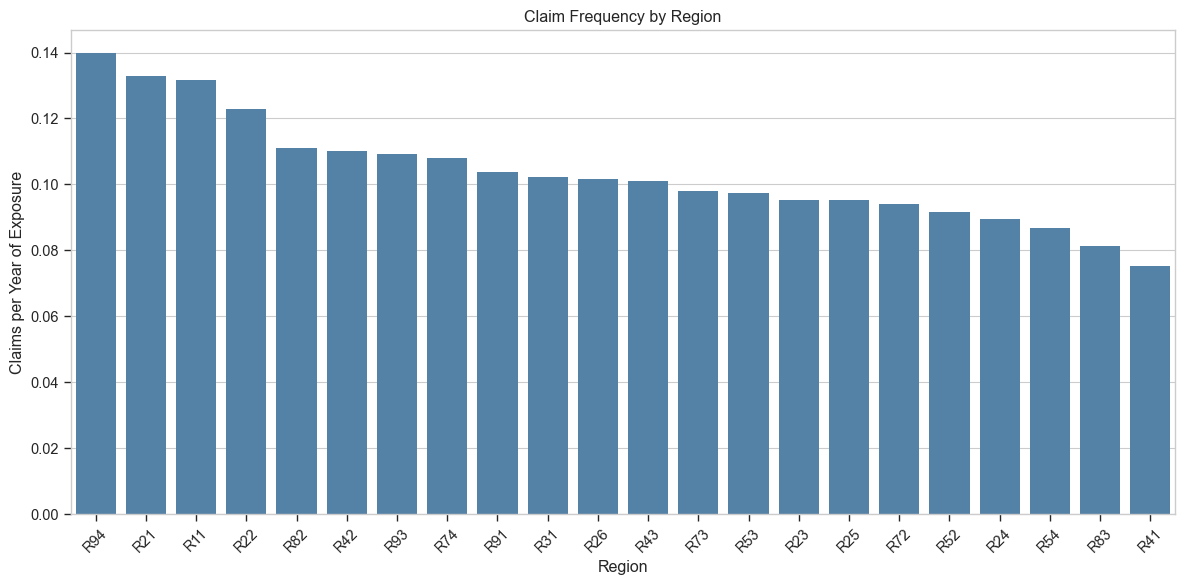

In [4]:
plt.figure(figsize=(12, 6))
grouped = merged_df.groupby("Region").agg(claims=("ClaimNb", "sum"), exposure=("Exposure", "sum"))
grouped["freq"] = grouped["claims"] / grouped["exposure"]
grouped = grouped.sort_values("freq", ascending=False)

sns.barplot(x=grouped.index, y=grouped["freq"], color="steelblue")
plt.title("Claim Frequency by Region")
plt.ylabel("Claims per Year of Exposure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Region R11 stands out with one of the highest claim frequencies despite having a large exposure volume, suggesting significant urban concentration (like the Paris area) or regional risk factors that warrant a territorial pricing multiplier.

### 3.2 Claim Frequency by Driver Age Band

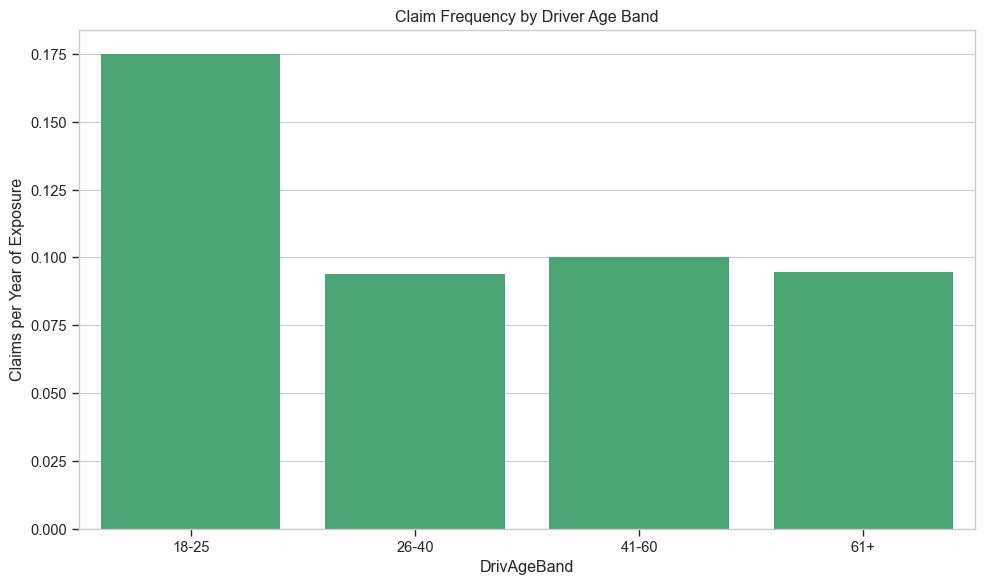

In [5]:
plt.figure(figsize=(10, 6))
grouped = merged_df.groupby("DrivAgeBand", observed=True).agg(claims=("ClaimNb", "sum"), exposure=("Exposure", "sum"))
grouped["freq"] = grouped["claims"] / grouped["exposure"]

sns.barplot(x=grouped.index, y=grouped["freq"], color="mediumseagreen")
plt.title("Claim Frequency by Driver Age Band")
plt.ylabel("Claims per Year of Exposure")
plt.tight_layout()
plt.show()

**Insight**: Drivers in the 18-25 age band exhibit a substantially higher claim frequency than any other group, validating the classic 'young driver' risk premium.

### 3.3 The Impact of Bonus-Malus

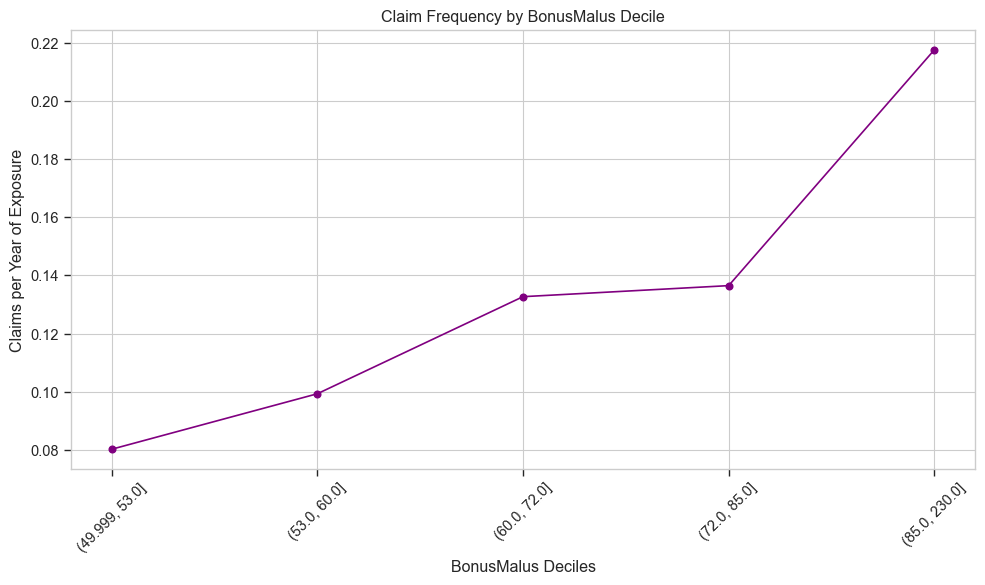

In [6]:
plt.figure(figsize=(10, 6))
df_bm = merged_df.copy()
df_bm["BM_Decile"] = pd.qcut(df_bm["BonusMalus"], q=10, duplicates="drop")
grouped = df_bm.groupby("BM_Decile", observed=True).agg(claims=("ClaimNb", "sum"), exposure=("Exposure", "sum"))
grouped["freq"] = grouped["claims"] / grouped["exposure"]

x_labels = [str(i) for i in grouped.index]
plt.plot(x_labels, grouped["freq"], marker="o", linestyle="-", color="purple")
plt.title("Claim Frequency by BonusMalus Decile")
plt.ylabel("Claims per Year of Exposure")
plt.xlabel("BonusMalus Deciles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: There is a steep, monotonic increase in claims as the BonusMalus score worsens. This proves the French bonus-malus system is a highly effective mechanism for tracking unobserved driver risk.

### 3.4 Severity Distribution

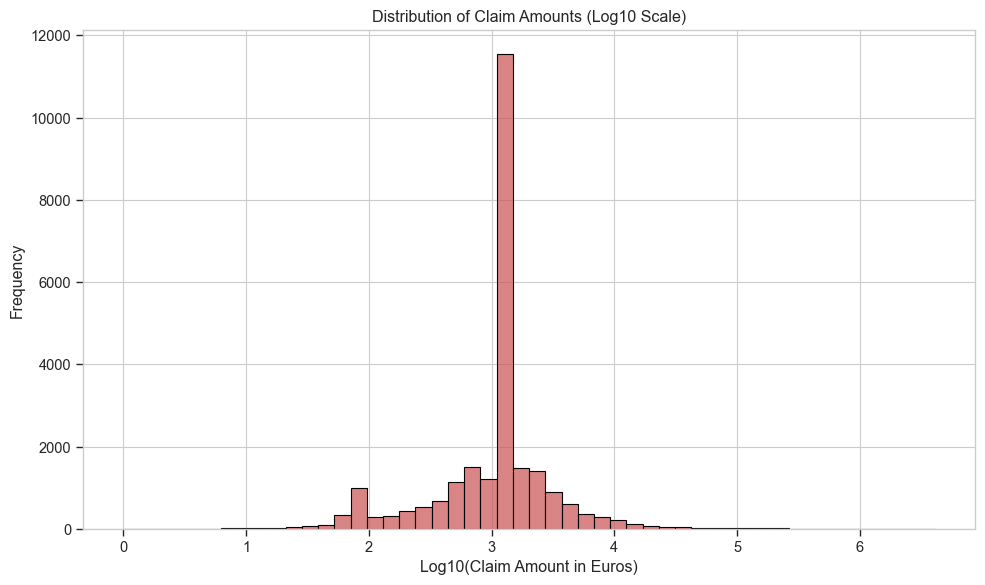

In [7]:
plt.figure(figsize=(10, 6))
claims = merged_df[merged_df["ClaimAmount_total"] > 0]["ClaimAmount_total"]
sns.histplot(np.log10(claims), bins=50, color="indianred")
plt.title("Distribution of Claim Amounts (Log10 Scale)")
plt.xlabel("Log10(Claim Amount in Euros)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Insight**: Claim amounts follow a heavy-tailed distribution, highly skewed to the right. A log-transformation reveals a normal-like curve, confirming that severity modeling requires Generalized Linear Models (like Gamma) rather than OLS.